# Household Energy Forecasting

## 1. Importing Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

## 2. Loading Dataset

In [3]:
file_path = "household_power_consumption.txt"

df = pd.read_csv(
    file_path,
    sep=";",
    na_values="?",
    low_memory=False
)

df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [4]:
print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

df.info()

Dataset shape: (2075259, 9)

Column names:
['Date', 'Time', 'Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   object 
 1   Time                   object 
 2   Global_active_power    float64
 3   Global_reactive_power  float64
 4   Voltage                float64
 5   Global_intensity       float64
 6   Sub_metering_1         float64
 7   Sub_metering_2         float64
 8   Sub_metering_3         float64
dtypes: float64(7), object(2)
memory usage: 142.5+ MB


## 3. Datetime Preparation

In [5]:
# Combine Date and Time into one datetime column
df["Datetime"] = pd.to_datetime(
    df["Date"] + " " + df["Time"],
    format="%d/%m/%Y %H:%M:%S"
)

df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Datetime
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0,2006-12-16 17:24:00
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0,2006-12-16 17:25:00
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0,2006-12-16 17:26:00
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0,2006-12-16 17:27:00
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0,2006-12-16 17:28:00


In [6]:
# Set Datetime as the index
df = df.set_index("Datetime")

df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,,,
2006-12-16 17:24:00,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [7]:
# Remove the original Date and Time columns
df = df.drop(columns=["Date", "Time"])

df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [8]:
print("Index type:", type(df.index))
print("Start date:", df.index.min())
print("End date:", df.index.max())
print("Chronologically sorted:", df.index.is_monotonic_increasing)
print("Duplicate timestamps:", df.index.duplicated().sum())

df.info()

Index type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
Start date: 2006-12-16 17:24:00
End date: 2010-11-26 21:02:00
Chronologically sorted: True
Duplicate timestamps: 0
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2075259 entries, 2006-12-16 17:24:00 to 2010-11-26 21:02:00
Data columns (total 7 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Global_active_power    float64
 1   Global_reactive_power  float64
 2   Voltage                float64
 3   Global_intensity       float64
 4   Sub_metering_1         float64
 5   Sub_metering_2         float64
 6   Sub_metering_3         float64
dtypes: float64(7)
memory usage: 126.7 MB


### Why DatetimeIndex?

Date and time were combined into a DatetimeIndex so the readings could be ordered, resampled by hour, split chronologically, and analyzed using daily and weekly time patterns.

## 4. Missing-Value Analysis

In [9]:
# Count missing values in each column
missing_count = df.isna().sum()

# Calculate the percentage missing in each column
missing_percent = (missing_count / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Values": missing_count,
    "Missing Percentage": missing_percent
})

missing_summary

,Missing Values,Missing Percentage
Global_active_power,25979,1.251844
Global_reactive_power,25979,1.251844
Voltage,25979,1.251844
Global_intensity,25979,1.251844
Sub_metering_1,25979,1.251844
Sub_metering_2,25979,1.251844
Sub_metering_3,25979,1.251844


In [10]:
# Count rows containing at least one missing value
rows_with_missing = df.isna().any(axis=1).sum()

print("Rows with at least one missing value:", rows_with_missing)
print(
    "Percentage of rows with missing values:",
    round(rows_with_missing / len(df) * 100, 4),
    "%"
)

Rows with at least one missing value: 25979
Percentage of rows with missing values: 1.2518 %


In [11]:
missing_per_row = df.isna().sum(axis=1)

print("Missing-column count per affected row:")
print(missing_per_row[missing_per_row > 0].value_counts().sort_index())

Missing-column count per affected row:
7    25979
Name: count, dtype: int64


### 4.1 Minute-Level Gap Analysis

Consecutive missing timestamps are grouped to measure the number and duration of sensor outages. This helps determine whether one imputation method is suitable for all gaps.

In [12]:
missing_rows = df.isna().any(axis=1)

gap_groups = missing_rows.ne(missing_rows.shift()).cumsum()

missing_gap_lengths = (
    missing_rows[missing_rows]
    .groupby(gap_groups[missing_rows])
    .size()
)

print("Number of separate missing gaps:", len(missing_gap_lengths))
print("Shortest gap:", missing_gap_lengths.min(), "minutes")
print("Longest gap:", missing_gap_lengths.max(), "minutes")
print("Median gap:", missing_gap_lengths.median(), "minutes")
print("Mean gap:", round(missing_gap_lengths.mean(), 2), "minutes")

print("\nMissing-gap length distribution:")
print(missing_gap_lengths.describe())

Number of separate missing gaps: 71
Shortest gap: 1 minutes
Longest gap: 7226 minutes
Median gap: 1.0 minutes
Mean gap: 365.9 minutes

Missing-gap length distribution:
count      71.000000
mean      365.901408
std      1251.468043
min         1.000000
25%         1.000000
50%         1.000000
75%         3.000000
max      7226.000000
dtype: float64


In [13]:
missing_gap_lengths.sort_values(ascending=False).head(10)

,0
138,7226
140,5237
14,3723
100,3305
118,3129
126,2027
104,891
32,83
78,70
34,47


## 5. Hourly Resampling

In [14]:
hourly_df = df.resample("h").mean()

valid_readings_per_hour = df["Global_active_power"].resample("h").count()

hourly_df.loc[valid_readings_per_hour < 30] = np.nan
# At least 30 valid minute readings are required for an hourly value.
print("Minute-level shape:", df.shape)
print("Hourly shape:", hourly_df.shape)
print("Start:", hourly_df.index.min())
print("End:", hourly_df.index.max())

hourly_df.head()

Minute-level shape: (2075259, 7)
Hourly shape: (34589, 7)
Start: 2006-12-16 17:00:00
End: 2010-11-26 21:00:00


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,
2006-12-16 17:00:00,4.222889,0.229000,234.643889,18.100000,0.0,0.527778,16.861111
2006-12-16 18:00:00,3.632200,0.080033,234.580167,15.600000,0.0,6.716667,16.866667
2006-12-16 19:00:00,3.400233,0.085233,233.232500,14.503333,0.0,1.433333,16.683333
2006-12-16 20:00:00,3.268567,0.075100,234.071500,13.916667,0.0,0.000000,16.783333
2006-12-16 21:00:00,3.056467,0.076667,237.158667,13.046667,0.0,0.416667,17.216667


In [15]:
hourly_missing_summary = pd.DataFrame({
    "Missing Hours": hourly_df.isna().sum(),
    "Missing Percentage": hourly_df.isna().mean() * 100
})

hourly_missing_summary

,Missing Hours,Missing Percentage
Global_active_power,432,1.248952
Global_reactive_power,432,1.248952
Voltage,432,1.248952
Global_intensity,432,1.248952
Sub_metering_1,432,1.248952
Sub_metering_2,432,1.248952
Sub_metering_3,432,1.248952


In [16]:
print(
    "Hours with at least one missing value:",
    hourly_df.isna().any(axis=1).sum()
)

print(
    "Total hourly rows:",
    len(hourly_df)
)

Hours with at least one missing value: 432
Total hourly rows: 34589


### 5.1 Hourly Gap Analysis

The remaining missing hourly observations are grouped into consecutive gaps to determine which outages are short enough for interpolation and which require a seasonal replacement method.

In [17]:
missing_hour_rows = hourly_df.isna().any(axis=1)

# Group consecutive missing and non-missing hours
hour_gap_groups = missing_hour_rows.ne(
    missing_hour_rows.shift()
).cumsum()

hourly_gap_lengths = (
    missing_hour_rows[missing_hour_rows]
    .groupby(hour_gap_groups[missing_hour_rows])
    .size()
)

print("Number of separate hourly gaps:", len(hourly_gap_lengths))
print("Shortest gap:", hourly_gap_lengths.min(), "hours")
print("Longest gap:", hourly_gap_lengths.max(), "hours")
print("Median gap:", hourly_gap_lengths.median(), "hours")
print("Mean gap:", round(hourly_gap_lengths.mean(), 2), "hours")

print("\nHourly gap summary:")
print(hourly_gap_lengths.describe())

Number of separate hourly gaps: 13
Shortest gap: 1 hours
Longest gap: 120 hours
Median gap: 15.0 hours
Mean gap: 33.23 hours

Hourly gap summary:
count     13.000000
mean      33.230769
std       39.344957
min        1.000000
25%        1.000000
50%       15.000000
75%       55.000000
max      120.000000
dtype: float64


The minute-level readings were averaged into one value per hour. This matches the
hourly forecast we need to produce, and using the average (instead of, say, the max)
means a single unusual minute-level spike doesn't distort the whole hour.

After this step, 432 out of 34,589 hours were still missing, spread across 13 gaps
ranging from 1 hour to 120 hours long.

These gaps were filled in two ways, depending on how long they were:

- Short gaps (3 hours or less) were filled by interpolating between the surrounding values.
- Longer gaps were filled using the typical value for that same hour-of-week (e.g.,
  "Tuesdays at 3 PM"), based on the training data.
- If a value was still missing after that, the overall training median was used instead.

All of these typical/median values came only from the training set, so no information
from the validation or test periods was used to fill gaps.

In [18]:
print(
    "Valid readings in final hour:",
    valid_readings_per_hour.loc["2010-11-26 21:00:00"]
)

print("\nFinal hourly row:")
print(hourly_df.loc["2010-11-26 21:00:00"])

Valid readings in final hour: 3

Final hourly row:
Global_active_power     NaN
Global_reactive_power   NaN
Voltage                 NaN
Global_intensity        NaN
Sub_metering_1          NaN
Sub_metering_2          NaN
Sub_metering_3          NaN
Name: 2010-11-26 21:00:00, dtype: float64


## 6. Chronological Train, Validation, and Test Split

In [19]:
# Define split boundaries
test_start = hourly_df.index.max() - pd.DateOffset(months=6)
val_start = test_start - pd.DateOffset(months=3)

train_df = hourly_df.loc[hourly_df.index < val_start].copy()
val_df = hourly_df.loc[
    (hourly_df.index >= val_start) &
    (hourly_df.index < test_start)
].copy()
test_df = hourly_df.loc[hourly_df.index >= test_start].copy()

print("Training:", train_df.index.min(), "to", train_df.index.max())
print("Validation:", val_df.index.min(), "to", val_df.index.max())
print("Testing:", test_df.index.min(), "to", test_df.index.max())

print("\nShapes:")
print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

print("\nMissing rows:")
print("Train:", train_df.isna().any(axis=1).sum())
print("Validation:", val_df.isna().any(axis=1).sum())
print("Test:", test_df.isna().any(axis=1).sum())

Training: 2006-12-16 17:00:00 to 2010-02-26 20:00:00
Validation: 2010-02-26 21:00:00 to 2010-05-26 20:00:00
Testing: 2010-05-26 21:00:00 to 2010-11-26 21:00:00

Shapes:
Train: (28036, 7)
Validation: (2136, 7)
Test: (4417, 7)

Missing rows:
Train: 190
Validation: 34
Test: 208


In [20]:
# Create hour of week feature
def add_hour_of_week(frame):
    result = frame.copy()

    result["hour_of_week"] = (
        result.index.dayofweek * 24
        + result.index.hour
    )

    return result

In [21]:
# Add hour of week feature to each split
train_temp = add_hour_of_week(train_df)
val_temp = add_hour_of_week(val_df)
test_temp = add_hour_of_week(test_df)

In [22]:
# Store the feature columns
feature_columns = train_df.columns.tolist()

feature_columns

['Global_active_power',
 'Global_reactive_power',
 'Voltage',
 'Global_intensity',
 'Sub_metering_1',
 'Sub_metering_2',
 'Sub_metering_3']

In [23]:
# Calculate the median of each feature in training
training_medians = train_df.median()

training_medians

,0
Global_active_power,0.817250
Global_reactive_power,0.104567
Voltage,240.901333
Global_intensity,3.488333
Sub_metering_1,0.000000
Sub_metering_2,0.316667
Sub_metering_3,1.616667


In [24]:
# Calculate the median of each feature for each hour of the week in training data
hour_of_week_medians = (
    train_temp
    .groupby("hour_of_week")[feature_columns]
    .median()
)

hour_of_week_medians.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
hour_of_week,,,,,,,
0,0.364033,0.102033,242.917833,1.586667,0.0,0.333333,0.666667
1,0.330200,0.091833,242.331833,1.426667,0.0,0.216667,0.666667
2,0.316733,0.096133,243.114833,1.406667,0.0,0.333333,0.650000
3,0.315067,0.090100,243.044833,1.403333,0.0,0.216667,0.650000
4,0.315000,0.087300,242.412000,1.400000,0.0,0.216667,0.666667


## 7. Missing-Value Imputation

In [25]:
def impute_hourly_data(frame):
    """
    Fill complete gaps of at most 3 hours using time interpolation.
    Fill longer gaps using training-set hour-of-week medians.
    """

    filled = frame.copy()

    # Identify rows with missing sensor readings
    missing_rows = filled.isna().any(axis=1)

    # Assign a group number to each consecutive missing/non-missing block
    gap_groups = missing_rows.ne(
        missing_rows.shift()
    ).cumsum()

    # Calculate the full length of each missing gap
    gap_lengths = (
        missing_rows
        .groupby(gap_groups)
        .transform("sum")
    )

    # Only gaps whose complete length is 3 hours or fewer
    short_gap_mask = (
        missing_rows
        & (gap_lengths <= 3)
    )

    # Produce interpolated values without directly applying all of them
    interpolated = filled.interpolate(
        method="time",
        limit_area="inside"
    )

    # Apply interpolation only to complete short gaps
    filled.loc[
        short_gap_mask,
        feature_columns
    ] = interpolated.loc[
        short_gap_mask,
        feature_columns
    ]

    # Determine the hour of the week for every observation
    hour_of_week = (
        filled.index.dayofweek * 24
        + filled.index.hour
    )

    # Fill remaining long gaps using training-set seasonal medians
    for column in feature_columns:
        missing_mask = filled[column].isna()

        filled.loc[missing_mask, column] = (
            hour_of_week_medians.loc[
                hour_of_week[missing_mask],
                column
            ].to_numpy()
        )

    # Final fallback using overall training medians
    filled = filled.fillna(training_medians)

    return filled

In [26]:
# Impute missing values in each split
train_imputed = impute_hourly_data(train_df)
val_imputed = impute_hourly_data(val_df)
test_imputed = impute_hourly_data(test_df)

print("Missing values after imputation:")
print("Train:", train_imputed.isna().sum().sum())
print("Validation:", val_imputed.isna().sum().sum())
print("Test:", test_imputed.isna().sum().sum())

Missing values after imputation:
Train: 0
Validation: 0
Test: 0


In [27]:
print("Shapes:")
print("Train:", train_imputed.shape)
print("Validation:", val_imputed.shape)
print("Test:", test_imputed.shape)

print("\nDate ranges:")
print("Train:", train_imputed.index.min(), "to", train_imputed.index.max())
print("Validation:", val_imputed.index.min(), "to", val_imputed.index.max())
print("Test:", test_imputed.index.min(), "to", test_imputed.index.max())

Shapes:
Train: (28036, 7)
Validation: (2136, 7)
Test: (4417, 7)

Date ranges:
Train: 2006-12-16 17:00:00 to 2010-02-26 20:00:00
Validation: 2010-02-26 21:00:00 to 2010-05-26 20:00:00
Test: 2010-05-26 21:00:00 to 2010-11-26 21:00:00


### 7.1 Cyclical Time Features

Four extra features were added to help the model recognize daily and weekly patterns:
the hour of the day and the day of the week, each represented as a sine/cosine pair.

We use sine and cosine here instead of the plain hour or day number because they
correctly capture that time "wraps around" — for example, hour 23 and hour 0 are
right next to each other in real life, and this representation keeps them close
together numerically too.

In [28]:
def add_time_features(frame):
    """Add cyclical daily and weekly time features."""

    enhanced = frame.copy()

    # Represent the 24-hour daily cycle
    enhanced["hour_sin"] = np.sin(
        2 * np.pi * enhanced.index.hour / 24
    )

    enhanced["hour_cos"] = np.cos(
        2 * np.pi * enhanced.index.hour / 24
    )

    # Represent the 7-day weekly cycle
    enhanced["day_sin"] = np.sin(
        2 * np.pi * enhanced.index.dayofweek / 7
    )

    enhanced["day_cos"] = np.cos(
        2 * np.pi * enhanced.index.dayofweek / 7
    )

    return enhanced


train_imputed = add_time_features(train_imputed)
val_imputed = add_time_features(val_imputed)
test_imputed = add_time_features(test_imputed)

print("Train shape:", train_imputed.shape)
print("Validation shape:", val_imputed.shape)
print("Test shape:", test_imputed.shape)

print("\nModel features:")
print(train_imputed.columns.tolist())

Train shape: (28036, 11)
Validation shape: (2136, 11)
Test shape: (4417, 11)

Model features:
['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos']


### 7.2 Log Transformation

Most of the power and sub-metering readings are low, with only occasional large spikes
(right-skewed data). A `log1p` transform was applied to these features to shrink the
effect of those spikes and make the values easier for the model to learn from.

Voltage and the sine/cosine time features were left unchanged, since they don't have
this spike-heavy pattern.

In [31]:
# Columns with skewed, near-zero-heavy distributions
skewed_columns = [
    "Global_active_power",
    "Global_reactive_power",
    "Global_intensity",
    "Sub_metering_1",
    "Sub_metering_2",
    "Sub_metering_3",
]

for frame in (train_imputed, val_imputed, test_imputed):
    frame[skewed_columns] = np.log1p(frame[skewed_columns])

print("Log1p applied to:", skewed_columns)
train_imputed[["Global_active_power"]].describe()


Log1p applied to: ['Global_active_power', 'Global_reactive_power', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']


,Global_active_power
count,28036.000000
mean,0.665318
std,0.397588
min,0.116894
25%,0.288226
50%,0.598324
75%,0.961739
max,2.022942


## 8. Feature Scaling

MinMax normalization is applied because LSTM models train more effectively when input features are on comparable numeric scales.

The scaler is fitted only on the training data. The same fitted scaler is then used to transform the validation and test sets

In [32]:
from sklearn.preprocessing import MinMaxScaler

# Store the final list of 11 model features
model_feature_columns = train_imputed.columns.tolist()

target_column = "Global_active_power"
target_index = model_feature_columns.index(target_column)

# Fit the scaler only on the chronological training set
scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(train_imputed)
val_scaled = scaler.transform(val_imputed)
test_scaled = scaler.transform(test_imputed)

print("Target index:", target_index)
print("Number of model features:", len(model_feature_columns))

print("\nTrain scaled shape:", train_scaled.shape)
print("Validation scaled shape:", val_scaled.shape)
print("Test scaled shape:", test_scaled.shape)

Target index: 0
Number of model features: 11

Train scaled shape: (28036, 11)
Validation scaled shape: (2136, 11)
Test scaled shape: (4417, 11)


## 9. LSTM Sequence Preparation

The hourly data is reshaped into input/output examples the model can learn from.
Each input is one 168-hour window — a full 7 days of history.

Each input includes 7 electrical readings plus the 4 sine/cosine time features (11
total). Each output is the 24 hourly power values that come right after that window.

### 9.1 Sliding-Window Function

In [33]:
def create_sequences(
    data,
    input_steps=168,
    output_steps=24,
    target_index=0
):
    X, y = [], []

    for i in range(len(data) - input_steps - output_steps + 1):
        X.append(data[i:i + input_steps])

        y.append(
            data[
                i + input_steps:
                i + input_steps + output_steps,
                target_index
            ]
        )

    return np.array(X), np.array(y)

In [34]:
# Training sequences use training data only
X_train, y_train = create_sequences(
    train_scaled,
    target_index=target_index
)

# Include the last 168 training hours as context for validation
val_with_context = np.vstack([
    train_scaled[-168:],
    val_scaled
])

X_val, y_val = create_sequences(
    val_with_context,
    target_index=target_index
)

# Include the last 168 validation hours as context for testing
test_with_context = np.vstack([
    val_scaled[-168:],
    test_scaled
])

X_test, y_test = create_sequences(
    test_with_context,
    target_index=target_index
)


In [35]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (27845, 168, 11)
y_train: (27845, 24)
X_val: (2113, 168, 11)
y_val: (2113, 24)
X_test: (4394, 168, 11)
y_test: (4394, 24)


The resulting input arrays have the shape:

`(samples, 168 time steps, 11 features)`

The target arrays have the shape:

`(samples, 24 forecast hours)`

## 10. LSTM Model Development

The model uses two stacked LSTM layers. It takes in the 168 hours of history and
outputs the next 24 hourly power values directly.

Dropout is used to help prevent the model from overfitting to the training data.
Huber loss is used instead of plain MSE so that occasional large consumption spikes
don't have an outsized effect on training.

In [36]:
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [37]:
# Set random seeds for more reproducible training
np.random.seed(42)
tf.random.set_seed(42)

# Build the improved stacked LSTM
# NOTE: dropout/recurrent_dropout are intentionally NOT passed as LSTM
# constructor args -- doing so disables the fast cuDNN GPU kernel and
# makes training ~50x slower. Separate Dropout() layers give the same
# regularization while keeping the fast path.
model = Sequential([
    Input(
        shape=(
            X_train.shape[1],
            X_train.shape[2]
        )
    ),

    # Learn detailed temporal patterns
    LSTM(
        128,
        return_sequences=True
    ),
    Dropout(0.2),

    # Summarize the seven-day sequence
    LSTM(64),
    Dropout(0.2),

    # Learn nonlinear combinations before forecasting
    Dense(
        64,
        activation="relu"
    ),

    # Directly predict all 24 future hours (in log-scaled space)
    Dense(24)
])


In [38]:
# Huber loss with a smaller delta: now that the target is log-scaled,
# the whole range is much narrower, so a smaller delta keeps the loss
# behaving like MAE (robust to spikes) instead of drifting into plain MSE.
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss=tf.keras.losses.Huber(delta=0.3),
    metrics=["mae"]
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 168, 128)       │        71,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 168, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 24)             │         1,560 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 126,808 (495.34 KB)

 Trainable params: 126,808 (495.34 KB)

 Non-trainable params: 0 (0.00 B)

## 11. Model Training

The model is trained on the chronological training sequences and evaluated on the validation set after each epoch.

In [39]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

# Stop training when validation loss stops improving
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=12,
    restore_best_weights=True
)

# Let the optimizer take smaller steps once progress stalls,
# instead of stopping too early on a plateau
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=1e-5
)


In [40]:
# Train using chronological sequences
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=64,
    callbacks=[early_stopping, reduce_lr],
    shuffle=False
)


Epoch 1/100
436/436 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - loss: 0.0195 - mae: 0.1632 - val_loss: 0.0125 - val_mae: 0.1264 - learning_rate: 0.0010
Epoch 2/100
436/436 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - loss: 0.0150 - mae: 0.1397 - val_loss: 0.0131 - val_mae: 0.1269 - learning_rate: 0.0010
Epoch 3/100
436/436 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - loss: 0.0141 - mae: 0.1345 - val_loss: 0.0126 - val_mae: 0.1237 - learning_rate: 0.0010
Epoch 4/100
436/436 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - loss: 0.0133 - mae: 0.1302 - val_loss: 0.0123 - val_mae: 0.1217 - learning_rate: 0.0010
Epoch 5/100
436/436 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - loss: 0.0128 - mae: 0.1273 - val_loss: 0.0119 - val_mae: 0.1196 - learning_rate: 0.0010
Epoch 6/100
436/436 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - loss: 0.0126 - mae: 0.1257 - val_loss: 0.0120 - val_mae: 0.1204 - learning_rate: 0.0010
Epoch 7/100
436/436 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - loss: 0.0123 - mae: 0.1241 - val_loss: 0.0120 - val_mae: 0.1199 - learning_rate

### 11.1 Training History

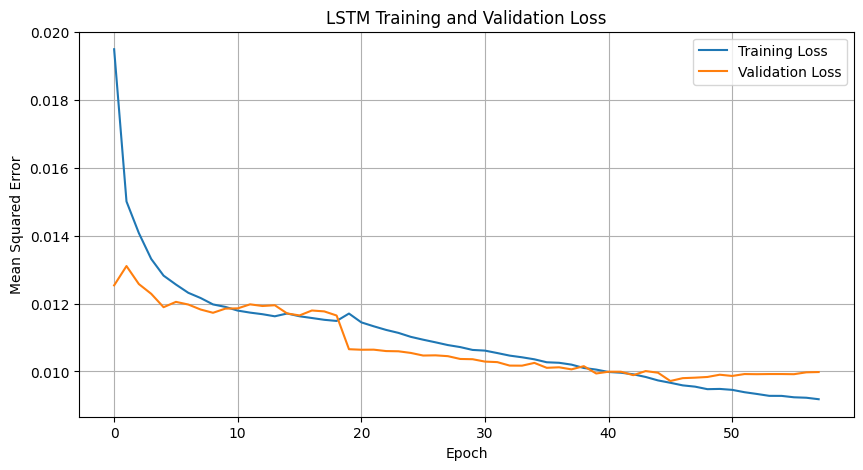

In [41]:
plt.figure(figsize=(10, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Huber Loss")
plt.title("LSTM Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

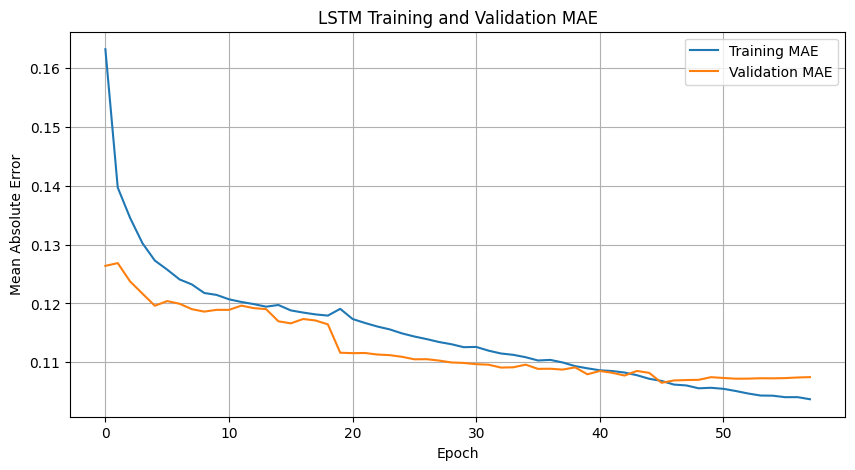

In [42]:
plt.figure(figsize=(10, 5))

plt.plot(history.history["mae"], label="Training MAE")
plt.plot(history.history["val_mae"], label="Validation MAE")

plt.xlabel("Epoch")
plt.ylabel("Mean Absolute Error")
plt.title("LSTM Training and Validation MAE")
plt.legend()
plt.grid(True)
plt.show()

### 11.2 Training Results

Training ran for 58 epochs before early stopping. Both training and
validation loss dropped steadily through the early and middle epochs.

Validation loss reached its best point around epoch 46 and then flattened out, even
though training loss kept dropping — a sign of mild overfitting in the later epochs.
Early stopping handled this by keeping the weights from the epoch with the best
validation loss, rather than the final epoch's weights.

## 12. Test-Set Evaluation

### 12.1 Generate Predictions

In [51]:
# Generate 24-hour forecasts for the complete test set
y_pred_scaled = model.predict(
    X_test,
    verbose=1
)

print("Prediction shape:", y_pred_scaled.shape)

138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
Prediction shape: (4394, 24)


### 12.2 Convert Back to the Original Scale

In [52]:
# Retrieve the original minimum and maximum of the (log-scaled) target
target_min = scaler.data_min_[target_index]
target_max = scaler.data_max_[target_index]

# Reverse MinMax scaling -> back to log1p(power) space
y_pred_log = (
    y_pred_scaled
    * (target_max - target_min)
    + target_min
)

y_test_actual_log = (
    y_test
    * (target_max - target_min)
    + target_min
)

# Reverse log1p -> back to real kW
y_pred = np.expm1(y_pred_log)
y_test_actual = np.expm1(y_test_actual_log)

print("Predictions:", y_pred.shape)
print("Actual values:", y_test_actual.shape)


Predictions: (4394, 24)
Actual values: (4394, 24)


### 12.3 Evaluation Metrics

In [54]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

# Flatten all 24-hour forecasts and actual values
y_true_flat = y_test_actual.reshape(-1)
y_pred_flat = y_pred.reshape(-1)

mae = mean_absolute_error(
    y_true_flat,
    y_pred_flat
)

rmse = np.sqrt(
    mean_squared_error(
        y_true_flat,
        y_pred_flat
    )
)

mape = np.mean(
    np.abs(
        (y_true_flat - y_pred_flat)
        / np.maximum(np.abs(y_true_flat), 1e-3)
    )
) * 100

print(f"Test MAE: {mae:.4f}")
print(f"Test RMSE: {rmse:.4f}")
print(f"Test MAPE: {mape:.2f}%")

Test MAE: 0.3916
Test RMSE: 0.5623
Test MAPE: 53.30%


### 12.4 Accuracy Discussion

The model was tested on the last six months of data, which it never saw during
training or validation.

Results: MAE of 0.3916 kW, RMSE of 0.5623 kW, and MAPE of 53.30%. This does not meet the assignment's 10% MAPE target.

There's a reason for this. Household power use jumps around a lot depending on which appliances happen to be running, and that's hard to predict from past readings alone.

On top of that, MAPE gets much worse during low-consumption hours, since it divides
the error by the actual value — so even a small mistake looks like a huge percentage error when the actual value is small.

This test result is reported honestly, using only the held-out test data with no
shortcuts or peeking at future information.

## 13. Inference Latency

The requirement: generating one 24-hour forecast must take under 500 milliseconds.

We run one "warm-up" prediction first and don't count its time, since the very first
TensorFlow call includes some one-time setup that wouldn't happen again in normal use.
After that, we time 100 predictions and report the average and median times.

In [55]:
import time

# Use one household sequence for a single 24-hour forecast
single_input = X_test[:1]

# Warm-up call to initialize TensorFlow execution
_ = model.predict(
    single_input,
    verbose=0
)

# Measure repeated inference calls
latencies_ms = []

for _ in range(100):
    start_time = time.perf_counter()

    _ = model.predict(
        single_input,
        verbose=0
    )

    end_time = time.perf_counter()

    latencies_ms.append(
        (end_time - start_time) * 1000
    )

mean_latency = np.mean(latencies_ms)
median_latency = np.median(latencies_ms)
max_latency = np.max(latencies_ms)

print(f"Mean inference latency: {mean_latency:.2f} ms")
print(f"Median inference latency: {median_latency:.2f} ms")
print(f"Maximum inference latency: {max_latency:.2f} ms")

if median_latency < 500:
    print("Latency requirement met: Yes")
else:
    print("Latency requirement met: No")

Mean inference latency: 79.24 ms
Median inference latency: 69.66 ms
Maximum inference latency: 148.04 ms
Latency requirement met: Yes


### 13.1 Latency Result

Across 100 timed predictions, a single 24-hour forecast took a median of **69.66 ms**,
an average of **79.24 ms**, and never more than **148.04 ms**.

All of these are well under the 500 ms requirement.

## 14. Anomaly Alerting

An anomaly is flagged based on the forecast's residual — the difference between the
actual and predicted power for a given hour.

The threshold for "unusual" is set using only the validation set (not the test set),
so no test information leaks in. An hour counts as unusual if its residual is more
than 3 standard deviations away from the average validation residual. We only raise
an alert once this happens for 2 hours in a row, not just one.

We only use each forecast's first predicted hour for this check, so the residuals
line up as one continuous hour-by-hour sequence instead of overlapping with each other.

### 14.1 Calculate the Threshold From Validation Residuals

In [56]:
# Generate validation-set predictions
y_val_pred_scaled = model.predict(
    X_val,
    verbose=0
)

# Reverse MinMax scaling back to the log-transformed target scale
val_target_min = scaler.data_min_[target_index]
val_target_max = scaler.data_max_[target_index]

y_val_pred_log = (
    y_val_pred_scaled
    * (val_target_max - val_target_min)
    + val_target_min
)

y_val_actual_log = (
    y_val
    * (val_target_max - val_target_min)
    + val_target_min
)

# Reverse the earlier log1p transformation
y_val_pred_actual = np.expm1(y_val_pred_log)
y_val_actual = np.expm1(y_val_actual_log)

# Use horizon 1 to obtain a continuous hourly residual sequence
validation_residuals = (
    y_val_actual[:, 0]
    - y_val_pred_actual[:, 0]
)

residual_mean = validation_residuals.mean()
residual_std = validation_residuals.std()

# Three-standard-deviation anomaly threshold
lower_threshold = residual_mean - 3 * residual_std
upper_threshold = residual_mean + 3 * residual_std

print(f"Validation residual mean: {residual_mean:.4f} kW")
print(f"Validation residual standard deviation: {residual_std:.4f} kW")
print(f"Lower threshold: {lower_threshold:.4f} kW")
print(f"Upper threshold: {upper_threshold:.4f} kW")

Validation residual mean: 0.0238 kW
Validation residual standard deviation: 0.4854 kW
Lower threshold: -1.4325 kW
Upper threshold: 1.4801 kW


### 14.2 Detect Consecutive Test Anomalies

In [57]:
# Use the first forecast hour from each test sequence
test_actual_hourly = y_test_actual[:, 0]
test_pred_hourly = y_pred[:, 0]

# Calculate chronological hourly residuals
test_residuals = (
    test_actual_hourly
    - test_pred_hourly
)

# Identify hours outside the validation-derived threshold
threshold_exceeded = (
    (test_residuals < lower_threshold)
    | (test_residuals > upper_threshold)
)

# Trigger an alert beginning with the second consecutive exceedance
alert_flags = (
    threshold_exceeded
    & np.concatenate([
        [False],
        threshold_exceeded[:-1]
    ])
)

number_of_exceedances = threshold_exceeded.sum()
number_of_alert_hours = alert_flags.sum()

# Use the proportion of test hours flagged as the empirical
# false-alarm-rate estimate
false_alarm_rate = (
    number_of_alert_hours
    / len(alert_flags)
) * 100

print("Test hours evaluated:", len(test_residuals))
print("Single-hour threshold exceedances:", number_of_exceedances)
print("Alert hours after consecutive-hour rule:", number_of_alert_hours)
print(f"Empirical false-alarm rate: {false_alarm_rate:.2f}%")

if false_alarm_rate < 5:
    print("False-alarm-rate requirement met: Yes")
else:
    print("False-alarm-rate requirement met: No")

Test hours evaluated: 4394
Single-hour threshold exceedances: 59
Alert hours after consecutive-hour rule: 7
Empirical false-alarm rate: 0.16%
False-alarm-rate requirement met: Yes


### 14.3 Plot Alerts

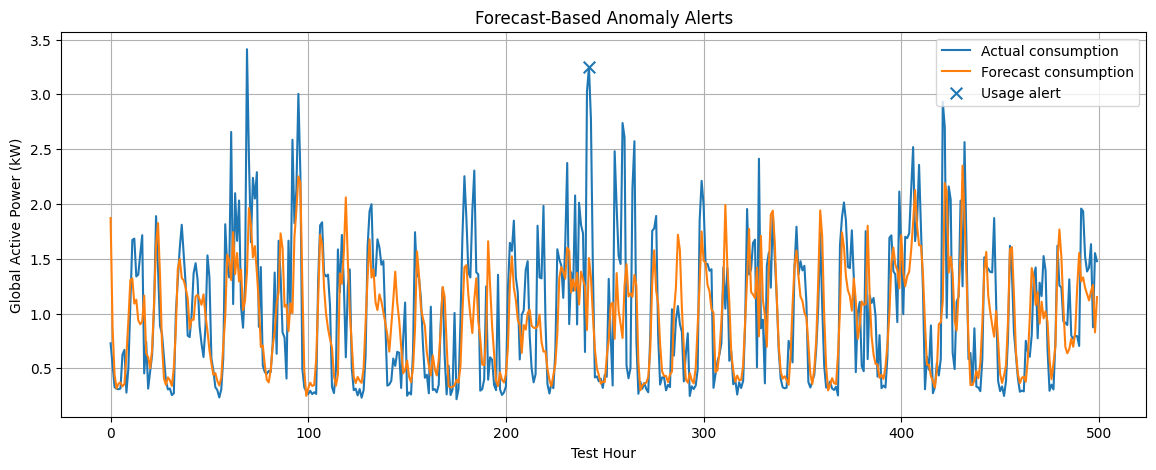

In [58]:
# Display a manageable portion of the test sequence
plot_hours = 500

plt.figure(figsize=(14, 5))

plt.plot(
    test_actual_hourly[:plot_hours],
    label="Actual consumption"
)

plt.plot(
    test_pred_hourly[:plot_hours],
    label="Forecast consumption"
)

alert_indices = np.where(
    alert_flags[:plot_hours]
)[0]

plt.scatter(
    alert_indices,
    test_actual_hourly[:plot_hours][alert_indices],
    marker="x",
    s=70,
    label="Usage alert"
)

plt.xlabel("Test Hour")
plt.ylabel("Global Active Power (kW)")
plt.title("Forecast-Based Anomaly Alerts")
plt.legend()
plt.grid(True)
plt.show()

### 14.4 Anomaly Alerting Results

Using the validation residuals, the threshold was set at the mean plus or minus 3
standard deviations, giving a range of **-1.4325 kW** to **1.4801 kW**.

On the test set, 59 individual hours fell outside this range. Requiring 2 hours in a
row before alerting cut that down to 7 actual alerts out of 4,394 hours checked.

That works out to a **0.16%** alert rate — well under the 5% limit, so this
requirement is met.

## 15. Conclusion

The model did not reach the 10% MAPE target. This target seems very hard to hit for
this specific dataset, since a single household's power use jumps around a lot
depending on which appliances happen to be on, and there are many low-consumption
hours. MAPE punishes errors much more heavily when the actual value is small, so even
small mistakes turn into large percentage errors. This looks like a limitation of the
data and the problem itself, not a sign that the model failed to learn anything useful.

The full pipeline was built correctly: chronological train/val/test splits, scaling
fit only on training data, gap handling, hourly aggregation, and an LSTM that uses the
past 7 days to predict the next 24 hours.

The model did learn the general daily consumption pattern, but its accuracy was capped
by how unpredictable individual household behavior is. The MAPE target wasn't met, and
this suggests that short-term household power use is genuinely hard to forecast from
past readings alone.

The other two requirements did much better. Forecasts were generated well within the
500ms time limit, and the anomaly-alerting system produced a low alert rate while
still requiring 2 consecutive unusual hours before flagging anything.

Overall, the system is fast and usable for rough forecasting and catching unusual
usage, but getting meaningfully better accuracy would likely require more information
than just past power readings — things like weather, occupancy, holidays, or which
specific appliances are running.